In [ ]:
# =========================================================
# ATTACK BEHAVIOR RULE MINING + VISUALIZATION
# =========================================================

import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer

from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)

# =========================================================
# STYLE
# =========================================================
sns.set_theme(style="whitegrid")

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_parquet(
    "../data_processed/cleaned_data.parquet"
)

# =========================================================
# 2. CLEAN DATA
# =========================================================
df.columns = [
    c.strip().lower()
    for c in df.columns
]

# =========================================================
# 3. SELECT FEATURES
# =========================================================
features = [
    "network_packet_size",
    "protocol_type",
    "login_attempts",
    "session_duration",
    "encryption_used",
    "ip_reputation_score",
    "failed_logins",
    "browser_type",
    "unusual_time_access"
]

target = "attack_detected"

df = df[features + [target]].copy()

# =========================================================
# 4. HANDLE NULLS
# =========================================================
df = df.fillna(0)

# =========================================================
# 5. DISCRETIZE NUMERIC FEATURES
# =========================================================
numeric_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins"
]

valid_numeric = []

for col in numeric_cols:

    if df[col].nunique() > 5:
        valid_numeric.append(col)

disc = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)

X_disc = disc.fit_transform(
    df[valid_numeric]
)

X_disc = pd.DataFrame(
    X_disc,
    columns=valid_numeric
)

# =========================================================
# 6. BUILD TRANSACTIONS
# =========================================================
transactions = {}

# =========================================================
# NUMERIC FEATURES
# =========================================================
for col in X_disc.columns:

    values = X_disc[col].values

    transactions[f"{col}_low"] = (
        values == 0
    ).astype(np.uint8)

    transactions[f"{col}_mid"] = (
        values == 1
    ).astype(np.uint8)

    transactions[f"{col}_high"] = (
        values == 2
    ).astype(np.uint8)

# =========================================================
# CATEGORICAL FEATURES
# =========================================================
categorical_cols = [
    "protocol_type",
    "encryption_used",
    "browser_type"
]

for col in categorical_cols:

    dummies = pd.get_dummies(
        df[col],
        prefix=col,
        dtype=np.uint8
    )

    for dcol in dummies.columns:
        transactions[dcol] = dummies[dcol].values

# =========================================================
# BOOLEAN FEATURE
# =========================================================
transactions["unusual_time_access"] = (
    df["unusual_time_access"]
    .astype(np.uint8)
)

# =========================================================
# TARGET
# =========================================================
transactions["attack_detected"] = (
    df[target]
    .astype(np.uint8)
)

# =========================================================
# FINAL TRANSACTION TABLE
# =========================================================
transactions = pd.DataFrame(
    transactions,
    dtype=np.uint8
)

print(
    "Transaction shape:",
    transactions.shape
)

# =========================================================
# MEMORY USAGE
# =========================================================
mem_mb = (
    transactions.memory_usage(deep=True)
    .sum()
    / 1024**2
)

print(f"RAM Usage: {mem_mb:.2f} MB")

# =========================================================
# 7. FP-GROWTH
# =========================================================
freq_items = fpgrowth(
    transactions.astype(bool),
    min_support=0.03,
    use_colnames=True
)

print(
    "Frequent itemsets:",
    len(freq_items)
)

# =========================================================
# 8. ASSOCIATION RULES
# =========================================================
rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.6
)

print(
    "Generated rules:",
    len(rules)
)

# =========================================================
# 9. KEEP ONLY ATTACK RULES
# =========================================================
rules = rules[
    rules["consequents"]
    .astype(str)
    .str.contains("attack_detected")
].copy()

# =========================================================
# REMOVE SELF TARGET RULES
# =========================================================
rules = rules[
    ~rules["antecedents"]
    .astype(str)
    .str.contains("attack_detected")
]

# =========================================================
# 10. RULE METRICS
# =========================================================
rules["rule_size"] = (
    rules["antecedents"]
    .apply(len)
)

rules["score"] = (
    rules["support"]
    * rules["confidence"]
    * rules["lift"]
)

# =========================================================
# SORT
# =========================================================
rules = rules.sort_values(
    by=[
        "score",
        "lift",
        "confidence"
    ],
    ascending=False
)

# =========================================================
# STRONG RULES
# =========================================================
strong_rules = rules[
    (rules["confidence"] > 0.7)
    &
    (rules["lift"] > 1.4)
    &
    (rules["rule_size"] >= 2)
]

# =========================================================
# DISPLAY
# =========================================================
cols = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "score",
    "rule_size"
]

print("\n==============================")
print("TOP ATTACK RULES")
print("==============================\n")

print(
    rules[cols]
    .head(20)
)

# =========================================================
# VISUALIZATION 1
# RULE METRIC DISTRIBUTION
# =========================================================
plt.figure(figsize=(10, 6))

sns.histplot(
    rules["confidence"],
    bins=20,
    kde=True
)

plt.title("Distribution of Rule Confidence")
plt.xlabel("Confidence")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# =========================================================
# VISUALIZATION 2
# SUPPORT VS CONFIDENCE
# =========================================================
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    sizes=(30, 300)
)

plt.title("Association Rules")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.tight_layout()
plt.show()

# =========================================================
# VISUALIZATION 3
# TOP RULES BY LIFT
# =========================================================
top_lift = rules.head(15).copy()

top_lift["rule_name"] = top_lift["antecedents"].astype(str)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_lift,
    x="lift",
    y="rule_name"
)

plt.title("Top Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rules")

plt.tight_layout()
plt.show()

# =========================================================
# VISUALIZATION 4
# FEATURE FREQUENCY
# =========================================================
feature_counter = {}

for ants in rules["antecedents"]:

    for item in ants:

        if item not in feature_counter:
            feature_counter[item] = 0

        feature_counter[item] += 1

feature_df = pd.DataFrame({
    "feature": list(feature_counter.keys()),
    "count": list(feature_counter.values())
})

feature_df = feature_df.sort_values(
    by="count",
    ascending=False
).head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_df,
    x="count",
    y="feature"
)

plt.title("Most Frequent Features in Attack Rules")
plt.xlabel("Frequency")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

gc.collect()

## **1. Chuẩn bị vấn đề**

### 1.1. Import các thư viện cần thiết

In [5]:
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer

from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)

### 1.2. Tải dữ liệu

In [6]:

df = pd.read_parquet(
    "../data_processed/cleaned_data.parquet"
)

df.columns = [
    c.strip().lower()
    for c in df.columns
]


### 1.3. Chọn các features

In [7]:
features = [
    "network_packet_size",
    "protocol_type",
    "login_attempts",
    "session_duration",
    "encryption_used",
    "ip_reputation_score",
    "failed_logins",
    "browser_type",
    "unusual_time_access"
]

target = "attack_detected"

df = df[features + [target]].copy()
df = df.fillna(0)

### 1.4. Rời rạc hóa các biến số

In [8]:
numeric_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins"
]

valid_numeric = []

for col in numeric_cols:

    if df[col].nunique() > 5:
        valid_numeric.append(col)

disc = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)

X_disc = disc.fit_transform(
    df[valid_numeric]
)

X_disc = pd.DataFrame(
    X_disc,
    columns=valid_numeric
)

## **3. Thực hiện vấn đề**

### 3.1. Xây dựng transactions

In [9]:
transactions = {}

# NUMERIC FEATURES
for col in X_disc.columns:

    values = X_disc[col].values

    transactions[f"{col}_low"] = (
        values == 0
    ).astype(np.uint8)

    transactions[f"{col}_mid"] = (
        values == 1
    ).astype(np.uint8)

    transactions[f"{col}_high"] = (
        values == 2
    ).astype(np.uint8)

# CATEGORICAL FEATURES
categorical_cols = [
    "protocol_type",
    "encryption_used",
    "browser_type"
]

for col in categorical_cols:

    dummies = pd.get_dummies(
        df[col],
        prefix=col,
        dtype=np.uint8
    )

    for dcol in dummies.columns:
        transactions[dcol] = dummies[dcol].values

# BOOLEAN FEATURE
transactions["unusual_time_access"] = (
    df["unusual_time_access"]
    .astype(np.uint8)
)

# TARGET
transactions["attack_detected"] = (
    df[target]
    .astype(np.uint8)
)

# FINAL TRANSACTION TABLE
transactions = pd.DataFrame(
    transactions,
    dtype=np.uint8
)

print(
    "Transaction shape:",
    transactions.shape
)

Transaction shape: (7571, 27)


### 3.2. Khởi tạo fpgrowth và luật kết hợp

In [10]:
freq_items = fpgrowth(
    transactions.astype(bool),
    min_support=0.03,
    use_colnames=True
)

print(
    "Frequent itemsets:",
    len(freq_items)
)

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.6
)

print(
    "Generated rules:",
    len(rules)
)

Frequent itemsets: 1981
Generated rules: 1301


### 3.3. Xây dựng luật kết hợp

In [11]:

# KEEP ONLY ATTACK RULES
rules = rules[
    rules["consequents"]
    .astype(str)
    .str.contains("attack_detected")
].copy()

# REMOVE SELF TARGET RULES
rules = rules[
    ~rules["antecedents"]
    .astype(str)
    .str.contains("attack_detected")
]

# RULE METRICS
rules["rule_size"] = (
    rules["antecedents"]
    .apply(len)
)

rules["score"] = (
    rules["support"]
    * rules["confidence"]
    * rules["lift"]
)

# SORT
rules = rules.sort_values(
    by=[
        "score",
        "lift",
        "confidence"
    ],
    ascending=False
)

# STRONG RULES
strong_rules = rules[
    (rules["confidence"] > 0.7)
    &
    (rules["lift"] > 1.4)
    &
    (rules["rule_size"] >= 2)
]

### 3.4. Kiểm tra kết quả

In [12]:
cols = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "score",
    "rule_size"
]

print("TOP ATTACK RULES")

print(
    rules[cols]
    .head(20)
)

TOP ATTACK RULES
                                            antecedents  \
1027  frozenset({failed_logins_high, login_attempts_...   
234   frozenset({ip_reputation_score_high, failed_lo...   
1040  frozenset({failed_logins_high, protocol_type_T...   
269   frozenset({ip_reputation_score_high, login_att...   
237   frozenset({failed_logins_high, ip_reputation_s...   
1030  frozenset({failed_logins_high, encryption_used...   
1099  frozenset({failed_logins_high, network_packet_...   
250   frozenset({failed_logins_high, ip_reputation_s...   
285   frozenset({ip_reputation_score_high, protocol_...   
1033  frozenset({failed_logins_high, browser_type_Ch...   
239   frozenset({ip_reputation_score_high, browser_t...   
77    frozenset({encryption_used_DES, failed_logins_...   
1010                  frozenset({browser_type_Unknown})   
281   frozenset({ip_reputation_score_high, failed_lo...   
1032  frozenset({failed_logins_high, protocol_type_T...   
273   frozenset({ip_reputation_score_hi

### 3.5. Biểu diễn luật qua đồ thị

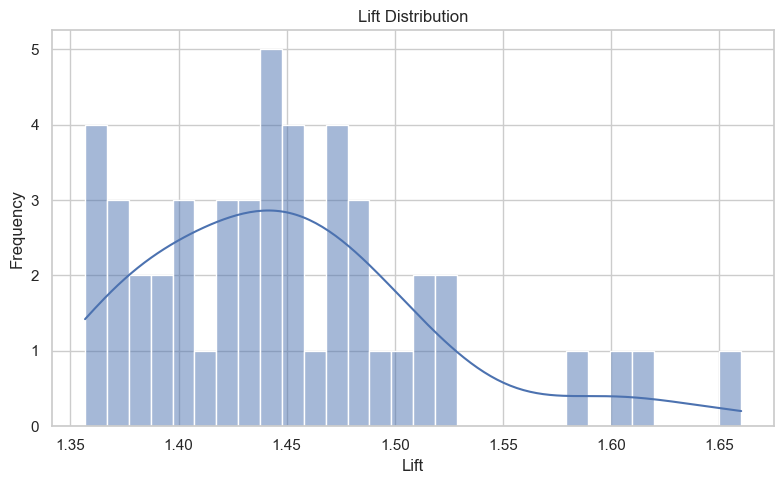

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rules["lift"],
    bins=30,
    kde=True
)

plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



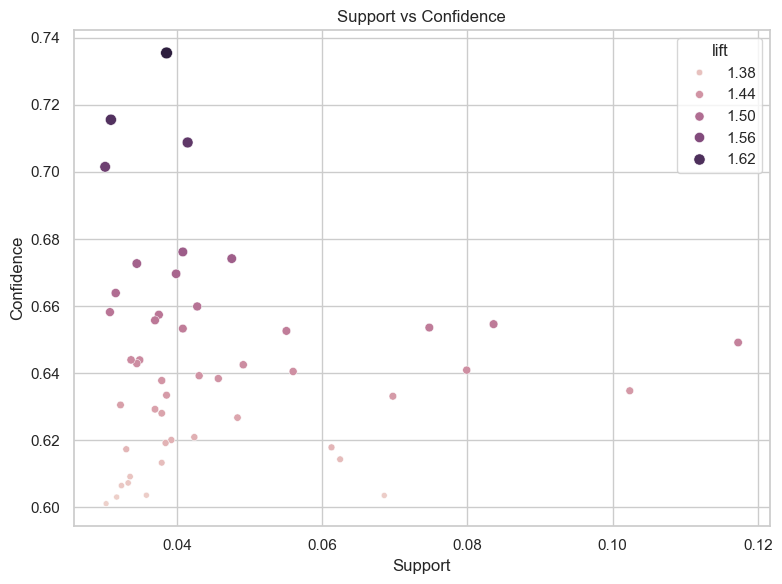

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift"
)

plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.tight_layout()
plt.show()

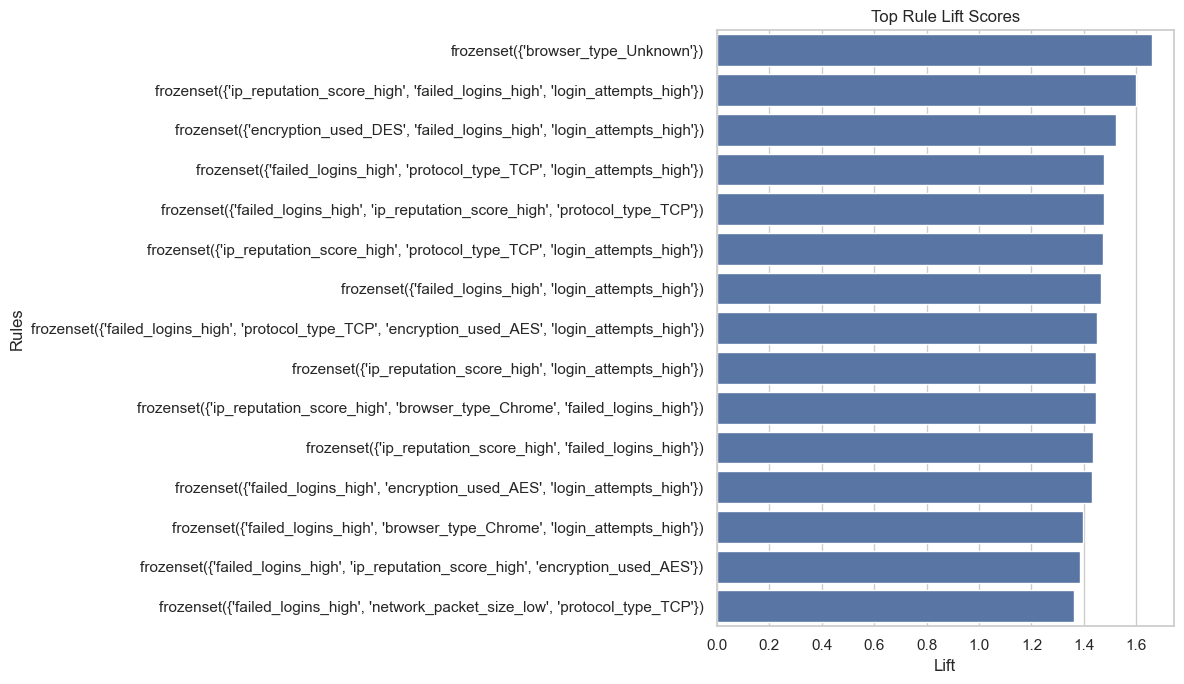

In [15]:
top_rules = rules.head(15).copy().sort_values(by="lift", ascending=False)

top_rules["rule_name"] = top_rules[
    "antecedents"
].astype(str)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_rules,
    x="lift",
    y="rule_name"
)

plt.title("Top Rule Lift Scores")
plt.xlabel("Lift")
plt.ylabel("Rules")

plt.tight_layout()
plt.show()